In [211]:
import pandas as pd
import numpy as np
from scipy.fft import fft
import re

# 1. Load Data & Map
catmap = pd.read_csv("data/catmap.csv")
consDF = pd.read_parquet("data/Consumer.pqt").drop(columns=["credit_score"])
consDF = consDF.dropna(subset=['DQ_TARGET'])

acctDF = pd.read_parquet("data/Account.pqt")
trxnDF = pd.read_parquet("data/Transaction.pqt").drop_duplicates()

acctDF['balance_date'] = pd.to_datetime(acctDF['balance_date'])
trxnDF['posted_date'] = pd.to_datetime(trxnDF['posted_date'])

# 2. Filter Valid Consumers
date_stats = acctDF.groupby('prism_consumer_id')['balance_date'].agg(['min', 'max'])
valid_ids = date_stats[(date_stats['max'] - date_stats['min']).dt.days <= 2].index

consDF = consDF[consDF['prism_consumer_id'].isin(valid_ids)]
acctDF = acctDF[acctDF['prism_consumer_id'].isin(valid_ids)]
trxnDF = trxnDF[trxnDF['prism_consumer_id'].isin(valid_ids)]

# 3. Transaction Processing
trxnDF['signed_amount'] = np.where(
    trxnDF['credit_or_debit'] == 'DEBIT', 
    -trxnDF['amount'], 
    trxnDF['amount']
)
trxnDF = trxnDF.sort_values(['prism_consumer_id', 'posted_date', 'prism_transaction_id'])
trxnDF['raw_cumsum'] = trxnDF.groupby('prism_consumer_id')['signed_amount'].cumsum()

snapshot = acctDF.sort_values('balance_date').groupby('prism_consumer_id').tail(1)
snapshot = snapshot.rename(columns={'balance': 'snapshot_balance', 'balance_date': 'snapshot_date'})

df_merged = trxnDF.merge(snapshot[['prism_consumer_id', 'snapshot_date', 'snapshot_balance']], on='prism_consumer_id', how='left')

anchor = df_merged[df_merged['posted_date'] <= df_merged['snapshot_date']].groupby('prism_consumer_id')['raw_cumsum'].last().rename('cumsum_at_snapshot')
df_merged = df_merged.merge(anchor, on='prism_consumer_id', how='left')

df_merged['running_balance'] = (df_merged['raw_cumsum'] - df_merged['cumsum_at_snapshot']) + df_merged['snapshot_balance']

# 4. Merge Category Names (Handling ID vs Name)
# Assumes catmap has columns like ['category_id', 'category']
df_merged = df_merged.merge(catmap, left_on='category', right_on="category_id", how='left').drop(columns=["category_x"])
df_merged['category'] = df_merged['category_y'] # 'category' is now the Name

history_df = df_merged[[
    'prism_consumer_id', 
    'posted_date', 
    'category_id',     # ID (for masking)
    'category',        # Name (for features)
    'amount', 
    'signed_amount',
    'credit_or_debit', 
    'running_balance'
]].merge(consDF[['prism_consumer_id', 'DQ_TARGET']], on='prism_consumer_id', how='inner')

spend_df = history_df[history_df['credit_or_debit'] == 'DEBIT'].copy()

# 5. Seasonal Features (Using Names)
def get_seasons(m):
    seasons = []
    if m in [11, 12, 1, 2]: seasons.append('Winter')
    if m in [3, 4, 5]:      seasons.append('Spring')
    if m in [6, 7, 8, 9]:   seasons.append('Summer')
    if m in [9, 10, 11]:    seasons.append('Fall')
    return seasons

seasonal_data = spend_df.copy()
seasonal_data['season_list'] = seasonal_data['posted_date'].dt.month.apply(get_seasons)
seasonal_data = seasonal_data.explode('season_list')

seasonal_features = seasonal_data.pivot_table(
    index='prism_consumer_id',
    columns=['season_list', 'category'], # Uses Name
    values='amount',
    aggfunc='sum',
    fill_value=0
)
seasonal_features.columns = [f'{s}_Cat_{c}' for s, c in seasonal_features.columns]

# 6. Global Stats
raw_stats = spend_df.groupby('prism_consumer_id')['amount'].agg(['mean', 'min', 'max']).add_prefix('trans_global_spend_')

# 7. Monthly Rolling (Using Names)
monthly_baskets = spend_df.groupby([
    'prism_consumer_id', 
    pd.Grouper(key='posted_date', freq='ME'), 
    'category' # Uses Name
])['amount'].sum().unstack(level='category', fill_value=0)

monthly_totals = monthly_baskets.sum(axis=1).to_frame('total_spend')

rolling_dfs = []
for m in [1, 3, 6, 12]:
    cat_roll = monthly_baskets.groupby('prism_consumer_id').rolling(window=m, min_periods=1).agg(['mean', 'max'])
    cat_roll.columns = [f'{col[0]}_{m}m_spend_{col[1]}' for col in cat_roll.columns]
    
    tot_roll = monthly_totals.groupby('prism_consumer_id').rolling(window=m, min_periods=1).agg(['mean', 'min', 'max'])
    tot_roll.columns = [f'{col[0]}_{m}m_{col[1]}' for col in tot_roll.columns]
    
    combined = pd.concat([cat_roll, tot_roll], axis=1)
    rolling_dfs.append(combined.groupby('prism_consumer_id').tail(1).reset_index(level=1, drop=True))

final_rolling = pd.concat(rolling_dfs, axis=1)

# 8. Income Features (Using ID for Safety)
income_cols = [3, 7, 45, 49]
income_mask = history_df['category_id'].isin(income_cols)

monthly_income = history_df[income_mask].groupby([
    'prism_consumer_id', 
    pd.Grouper(key='posted_date', freq='ME')
])['signed_amount'].sum()

def calc_fft_features(series):
    if isinstance(series.index, pd.MultiIndex):
        series = series.droplevel(0)
    series = series.asfreq('ME', fill_value=0)
    n = len(series)
    if n < 2:
        return pd.Series([series.mean(), 0.0], index=['income_fft_dc', 'income_fft_stability'])
    y = fft(series.values)
    dc = np.abs(y[0]) / n
    stability = np.abs(y[1]) / n
    return pd.Series([dc, stability], index=['income_fft_dc', 'income_fft_stability'])

fft_features = monthly_income.groupby('prism_consumer_id').apply(calc_fft_features).unstack()

targets = history_df[['prism_consumer_id', 'DQ_TARGET']].drop_duplicates().set_index('prism_consumer_id')
final_rolling['income_data_missing'] = fft_features['income_fft_dc'].isna().astype(int)

# 9. Final Merge
final_product = (final_rolling
                 .join(raw_stats, how='left')
                 .join(fft_features, how='left')
                 .join(seasonal_features, how='left')
                 .join(targets, how='inner')
                 .fillna(0))

# 10. SANITIZATION: Clean Column Names for XGBoost
# Replaces "Food & Dining" with "Food___Dining" and removes spaces
final_product.columns = [
    re.sub(r'[^a-zA-Z0-9_]', '_', str(col)) for col in final_product.columns
]

final_product

,,ACCOUNT_FEES_1m_spend_mean,ACCOUNT_FEES_1m_spend_max,ATM_CASH_1m_spend_mean,ATM_CASH_1m_spend_max,AUTOMOTIVE_1m_spend_mean,AUTOMOTIVE_1m_spend_max,AUTO_LOAN_1m_spend_mean,AUTO_LOAN_1m_spend_max,BANKING_CATCH_ALL_1m_spend_mean,BANKING_CATCH_ALL_1m_spend_max,...,Winter_Cat_OVERDRAFT,Winter_Cat_PETS,Winter_Cat_RENT,Winter_Cat_RISK_CATCH_ALL,Winter_Cat_RTO_LTO,Winter_Cat_SELF_TRANSFER,Winter_Cat_TAX,Winter_Cat_TRANSPORATION,Winter_Cat_TRAVEL,DQ_TARGET
prism_consumer_id,posted_date,,,,,,,,,,,,,,,,,,,,,
0,2021-09-30,0.0,0.0,500.00,500.00,42.43,42.43,0.0,0.0,0.00,0.00,...,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0
1,2021-07-31,0.0,0.0,600.00,600.00,28.74,28.74,0.0,0.0,0.00,0.00,...,0.0,35.43,0.0,0.0,0.0,1489.00,0.00,0.00,0.00,0.0
10,2022-02-28,0.0,0.0,580.00,580.00,77.01,77.01,0.0,0.0,0.00,0.00,...,0.0,0.00,0.0,0.0,0.0,750.00,0.00,5.00,0.00,0.0
1000,2023-02-28,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.00,...,0.0,0.00,0.0,0.0,0.0,15635.65,0.00,0.00,0.00,0.0
10000,2022-03-31,0.0,0.0,0.00,0.00,89.18,89.18,0.0,0.0,0.00,0.00,...,0.0,269.55,0.0,0.0,0.0,0.00,0.00,3239.73,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,2022-02-28,0.0,0.0,0.00,0.00,60.22,60.22,0.0,0.0,0.00,0.00,...,0.0,446.51,0.0,0.0,0.0,2094.00,47.13,0.00,207.54,0.0
995,2021-11-30,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.00,...,0.0,0.00,1136.4,0.0,0.0,0.00,0.00,0.00,0.00,0.0
997,2022-04-30,0.0,0.0,1900.00,1900.00,0.00,0.00,0.0,0.0,0.00,0.00,...,0.0,0.00,0.0,0.0,0.0,19142.20,0.00,0.00,0.00,0.0


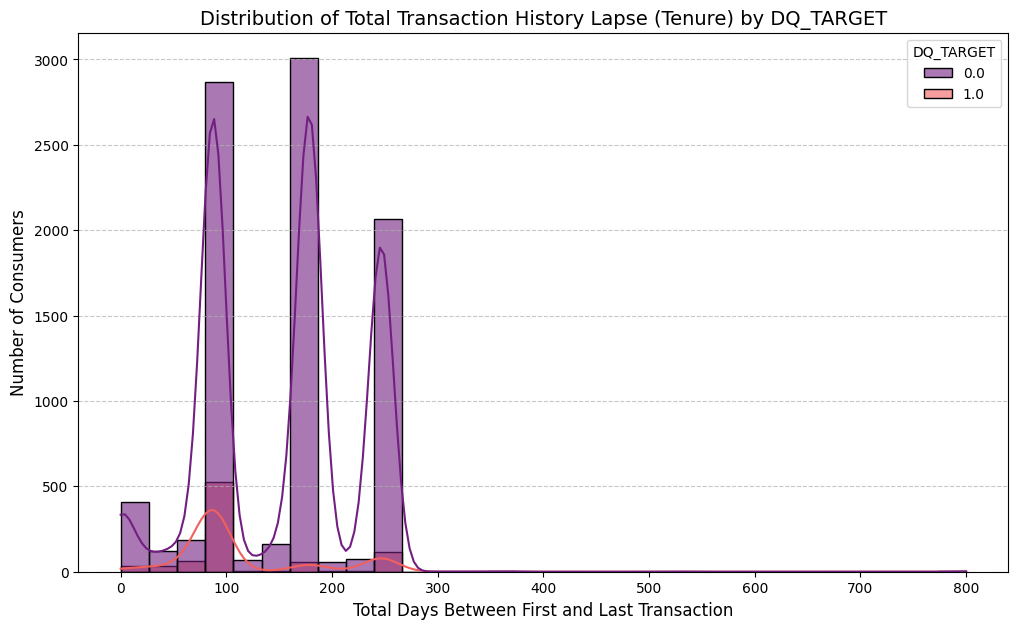

In [253]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Merge transaction data with consumer labels to get DQ_TARGET
df = trxnDF.merge(consDF[['prism_consumer_id', 'DQ_TARGET']], on='prism_consumer_id', how='inner')
lapse_df = df.groupby(['prism_consumer_id', 'DQ_TARGET'])['posted_date'].agg(['min', 'max']).reset_index()

# 3. Calculate the lapse time in days
# We add +1 so that a same-day transaction reflects as 1 day of history
lapse_df['lapse_days'] = (lapse_df['max'] - lapse_df['min']).dt.days

# 4. Create the distribution plot
plt.figure(figsize=(12, 7))
sns.histplot(
    data=lapse_df, 
    x='lapse_days', 
    hue='DQ_TARGET', 
    kde=True, 
    bins=30, 
    palette='magma', 
    alpha=0.6,
    multiple="layer"
)

plt.title('Distribution of Total Transaction History Lapse (Tenure) by DQ_TARGET', fontsize=14)
plt.xlabel('Total Days Between First and Last Transaction', fontsize=12)
plt.ylabel('Number of Consumers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


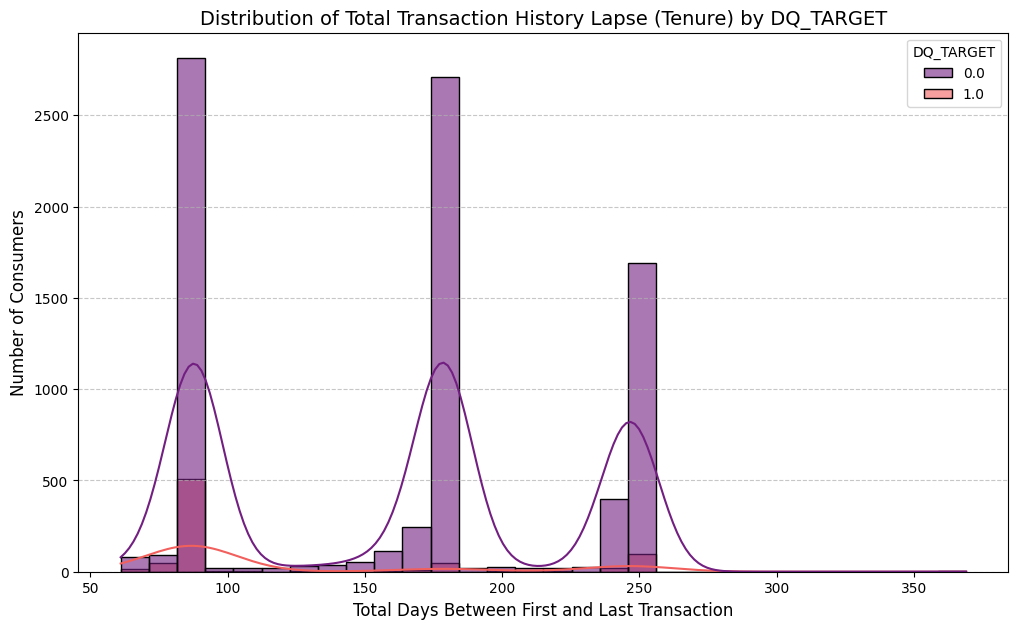

In [260]:
plt.figure(figsize=(12, 7))
sns.histplot(
    data=lapse_df[
        (lapse_df["lapse_days"] < 400)&
        (lapse_df["lapse_days"] > 60)
        ], 
    x='lapse_days', 
    hue='DQ_TARGET', 
    kde=True, 
    bins=30, 
    palette='magma', 
    alpha=0.6,
    multiple="layer"
)

plt.title('Distribution of Total Transaction History Lapse (Tenure) by DQ_TARGET', fontsize=14)
plt.xlabel('Total Days Between First and Last Transaction', fontsize=12)
plt.ylabel('Number of Consumers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

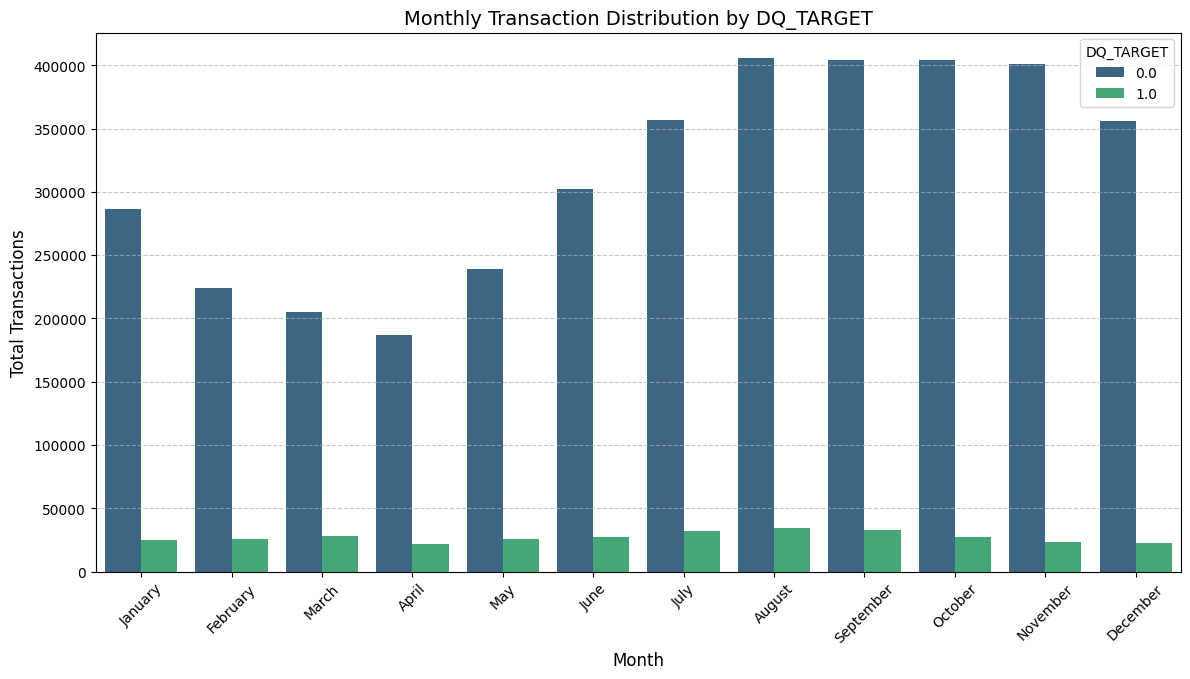

In [262]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure posted_date is in datetime format
df['posted_date'] = pd.to_datetime(df['posted_date'])

# 2. Extract the month and month name
# We extract the month number for sorting and name for labeling
df['month_num'] = df['posted_date'].dt.month
df['month_name'] = df['posted_date'].dt.month_name()

# 3. Create a monthly summary
# Option A: Total transactions per month
monthly_dist = df.groupby(['month_num', 'month_name', 'DQ_TARGET']).size().reset_index(name='transaction_count')

# Option B: Or unique consumers per month
# monthly_dist = df.groupby(['month_num', 'month_name', 'DQ_TARGET'])['prism_consumer_id'].nunique().reset_index(name='unique_consumers')

# 4. Create the plot
plt.figure(figsize=(14, 7))
sns.barplot(
    data=monthly_dist.sort_values('month_num'), 
    x='month_name', 
    y='transaction_count', 
    hue='DQ_TARGET', 
    palette='viridis'
)

plt.title('Monthly Transaction Distribution by DQ_TARGET', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Transactions', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title='DQ_TARGET')
plt.show()

In [281]:
catmap

,category_id,category
0,0,SELF_TRANSFER
1,1,EXTERNAL_TRANSFER
2,2,DEPOSIT
3,3,PAYCHECK
4,4,MISCELLANEOUS
5,5,PAYCHECK_PLACEHOLDER
6,6,REFUND
7,7,INVESTMENT_INCOME
8,8,OTHER_BENEFITS
9,9,UNEMPLOYMENT_BENEFITS


Analyzing Categories: [31 41 39 34 20  0  4 49]


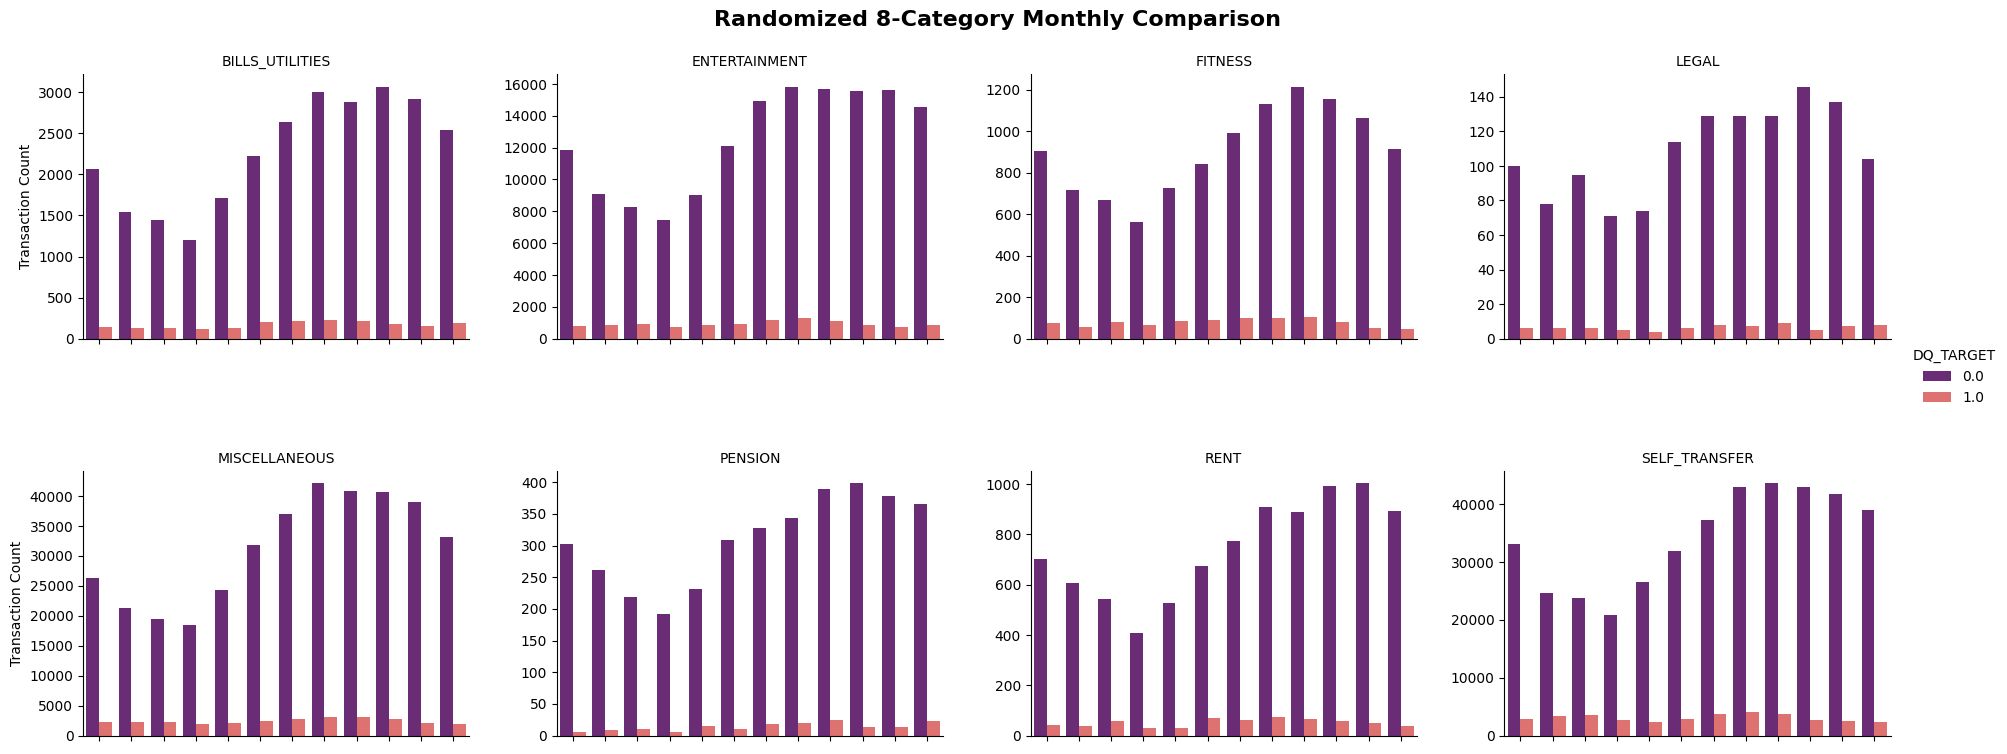

In [285]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Generate a random sequence of 8 unique categories from 1 to 49
# We use replace=False to ensure we don't get the same category twice
available_categories = df['category'].unique()
target_categories = np.random.choice(available_categories, 8, replace=False)

print(f"Analyzing Categories: {target_categories}")

# 2. Filter and Prepare
sub_df = df[df['category'].isin(target_categories)].copy()
sub_df['posted_date'] = pd.to_datetime(sub_df['posted_date'])

# 3. Extract Month info and Map Names
sub_df['month_num'] = sub_df['posted_date'].dt.month
sub_df['month_name'] = sub_df['posted_date'].dt.month_name()

# Using catmap to get the readable label
sub_df['cat_name'] = sub_df['category'].map(lambda x: catmap.iloc[x]['category'])

# 4. Aggregate counts
grid_counts = sub_df.groupby(['cat_name', 'month_num', 'month_name', 'DQ_TARGET']).size().reset_index(name='tx_count')
grid_counts = grid_counts.sort_values(['cat_name', 'month_num'])

# 5. Plotting using FacetGrid
# 'sharey=False' is crucial because transaction volumes vary wildly between categories
g = sns.catplot(
    data=grid_counts, 
    x='month_name', 
    y='tx_count', 
    hue='DQ_TARGET', 
    col='cat_name', 
    kind='bar', 
    col_wrap=4, 
    height=4, 
    aspect=1.2,
    palette='magma',
    sharey=False 
)

# 6. Formatting
g.set_xticklabels(rotation=45)
g.set_axis_labels("", "Transaction Count")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9, hspace=0.5)
g.fig.suptitle('Randomized 8-Category Monthly Comparison', fontsize=16, fontweight='bold')

plt.show()

In [212]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

X = final_product.drop(columns=['DQ_TARGET'])
y = final_product['DQ_TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3 , stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

train_probs = model.predict_proba(X_train_scaled)[:, 1]
test_probs = model.predict_proba(X_test_scaled)[:, 1]

print(f"Train ROC AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Test ROC AUC:  {roc_auc_score(y_test, test_probs):.4f}")

Train ROC AUC: 0.8513
Test ROC AUC:  0.6509


In [213]:
import xgboost as xgb

X = final_product.drop(columns=['DQ_TARGET', 'posted_date', 'prism_consumer_id'], errors='ignore')
y = final_product['DQ_TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)


ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.5,
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

train_probs = model.predict_proba(X_train)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

print(f"\nTrain ROC AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Test ROC AUC:  {roc_auc_score(y_test, test_probs):.4f}")

[0]	validation_0-logloss:0.67975	validation_1-logloss:0.68009
[100]	validation_0-logloss:0.35801	validation_1-logloss:0.42849
[200]	validation_0-logloss:0.24962	validation_1-logloss:0.36170
[300]	validation_0-logloss:0.17521	validation_1-logloss:0.31860
[400]	validation_0-logloss:0.12391	validation_1-logloss:0.29388
[500]	validation_0-logloss:0.08959	validation_1-logloss:0.28115
[600]	validation_0-logloss:0.06527	validation_1-logloss:0.27151
[700]	validation_0-logloss:0.04900	validation_1-logloss:0.26981
[800]	validation_0-logloss:0.03663	validation_1-logloss:0.27043
[900]	validation_0-logloss:0.02760	validation_1-logloss:0.27315
[999]	validation_0-logloss:0.02153	validation_1-logloss:0.27698

Train ROC AUC: 1.0000
Test ROC AUC:  0.7769


In [214]:
sparsity = (final_product == 0).mean()
drop_sparse = sparsity[sparsity > 0.97].index
print(f"Dropping {len(drop_sparse)} columns that are mostly zeros (e.g., rare categories).")

cols_to_drop = list(set(drop_sparse))

safe_cols = ['prism_consumer_id', 'posted_date', 'DQ_TARGET', 'income_data_missing']
cols_to_drop = [c for c in cols_to_drop if c not in safe_cols]

final_lean = final_product.drop(columns=cols_to_drop)

print(f"\nOriginal Shape: {final_product.shape}")
print(f"New Lean Shape: {final_lean.shape}")

Dropping 47 columns that are mostly zeros (e.g., rare categories).

Original Shape: (9678, 487)
New Lean Shape: (9678, 441)


In [215]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

X = final_lean.drop(columns=['DQ_TARGET'])
y = final_lean['DQ_TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3 , stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

train_probs = model.predict_proba(X_train_scaled)[:, 1]
test_probs = model.predict_proba(X_test_scaled)[:, 1]

print(f"Train ROC AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Test ROC AUC:  {roc_auc_score(y_test, test_probs):.4f}")

Train ROC AUC: 0.8431
Test ROC AUC:  0.6797


In [216]:
import xgboost as xgb

X = final_lean.drop(columns=['DQ_TARGET', 'posted_date', 'prism_consumer_id'], errors='ignore')
y = final_lean['DQ_TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)


ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.5,
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

train_probs = model.predict_proba(X_train)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

print(f"\nTrain ROC AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Test ROC AUC:  {roc_auc_score(y_test, test_probs):.4f}")

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

# 2. Sort by importance (highest first)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 3. Display Top 10 rows
print("\n--- TOP 10 PREDICTIVE FEATURES ---")
print(importance_df.head(10).to_string(index=False))

[0]	validation_0-logloss:0.68037	validation_1-logloss:0.68368
[100]	validation_0-logloss:0.34089	validation_1-logloss:0.43163
[200]	validation_0-logloss:0.23790	validation_1-logloss:0.37510
[300]	validation_0-logloss:0.16338	validation_1-logloss:0.33893
[400]	validation_0-logloss:0.11451	validation_1-logloss:0.32233
[500]	validation_0-logloss:0.08282	validation_1-logloss:0.31424
[600]	validation_0-logloss:0.06077	validation_1-logloss:0.31295
[700]	validation_0-logloss:0.04527	validation_1-logloss:0.31624
[800]	validation_0-logloss:0.03486	validation_1-logloss:0.32048
[900]	validation_0-logloss:0.02698	validation_1-logloss:0.32751
[999]	validation_0-logloss:0.02116	validation_1-logloss:0.33306

Train ROC AUC: 1.0000
Test ROC AUC:  0.7152

--- TOP 10 PREDICTIVE FEATURES ---
                     Feature  Importance
  ACCOUNT_FEES_3m_spend_mean    0.010705
         Summer_Cat_MORTGAGE    0.009211
        Winter_Cat_GROCERIES    0.008980
     OVERDRAFT_3m_spend_mean    0.007522
         Spr

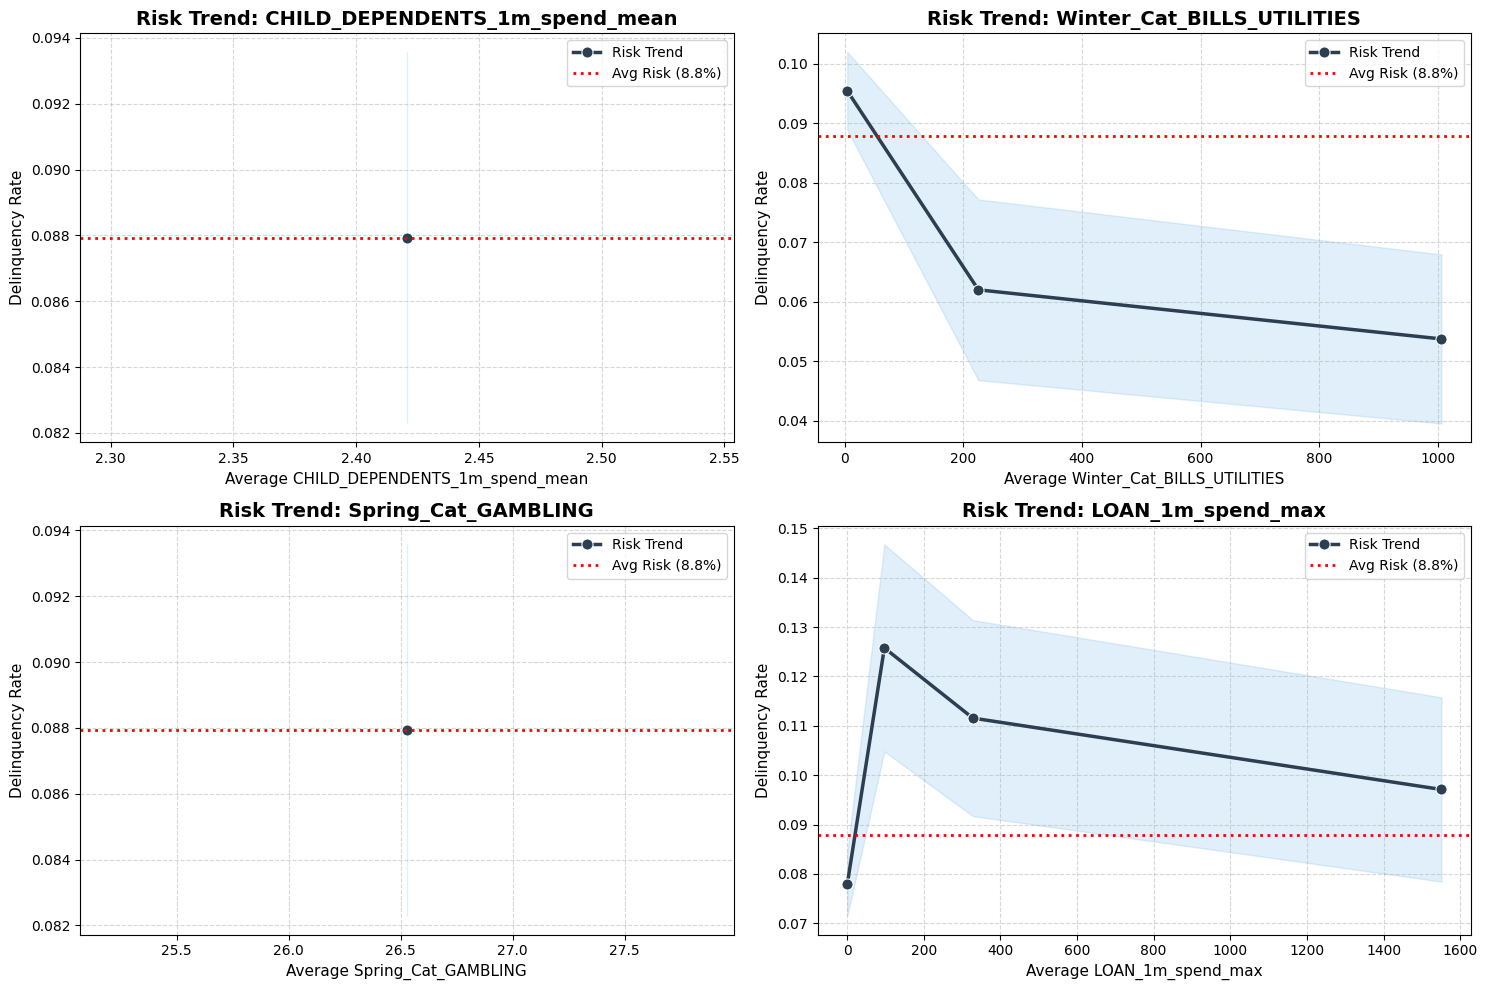

In [217]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_feature_risk_trends(df, features, target='DQ_TARGET', bins=10):
    """
    Plots the trend of Delinquency Risk against specific features using decile binning.
    Includes error bands and a global average baseline.
    """
    # Calculate grid size dynamically
    n_features = len(features)
    n_cols = 2
    n_rows = (n_features + 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    # Styling
    line_color = '#2c3e50'  # Dark Blue-Grey
    fill_color = '#3498db'  # Bright Blue
    
    for i, col in enumerate(features):
        ax = axes[i]
        
        # Create a working copy to avoid SettingWithCopy warnings
        temp_df = df[[col, target]].copy()
        
        # 1. Robust Binning Logic
        try:
            # 'duplicates="drop"' merges bins if many users have the exact same value (e.g., 0)
            temp_df['bin'] = pd.qcut(temp_df[col], q=bins, duplicates='drop')
        except ValueError:
            # Fallback: If qcut fails (too many identical values), use rank-based binning
            temp_df['bin'] = pd.qcut(temp_df[col].rank(method='first'), q=bins)

        # 2. Aggregation: Calculate Mean Risk and Standard Error per bin
        agg_data = temp_df.groupby('bin', observed=True).agg({
            col: 'mean',
            target: ['mean', 'sem'] # Mean and Standard Error
        })
        
        # Flatten columns
        agg_data.columns = ['avg_feature_val', 'risk_rate', 'std_err']
        agg_data = agg_data.reset_index()
        
        # 3. Plotting
        # Main Trend Line
        sns.lineplot(
            ax=ax, x=agg_data['avg_feature_val'], y=agg_data['risk_rate'],
            marker='o', markersize=8, linewidth=2.5, color=line_color, label='Risk Trend'
        )
        
        # Confidence Interval (Shaded Area: Mean +/- 1.96 * Standard Error)
        lower = agg_data['risk_rate'] - 1.96 * agg_data['std_err']
        upper = agg_data['risk_rate'] + 1.96 * agg_data['std_err']
        ax.fill_between(agg_data['avg_feature_val'], lower, upper, color=fill_color, alpha=0.15)
        
        # 4. Reference Lines & Labels
        global_risk = df[target].mean()
        ax.axhline(global_risk, color='red', linestyle=':', linewidth=2, label=f'Avg Risk ({global_risk:.1%})')
        
        ax.set_title(f'Risk Trend: {col}', fontsize=14, fontweight='bold')
        ax.set_xlabel(f'Average {col}', fontsize=11)
        ax.set_ylabel('Delinquency Rate', fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend()

    # Hide empty subplots if feature count is odd
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

import random

features_to_plot = random.choices(final_product.columns,k=4)

plot_feature_risk_trends(final_product, features_to_plot)

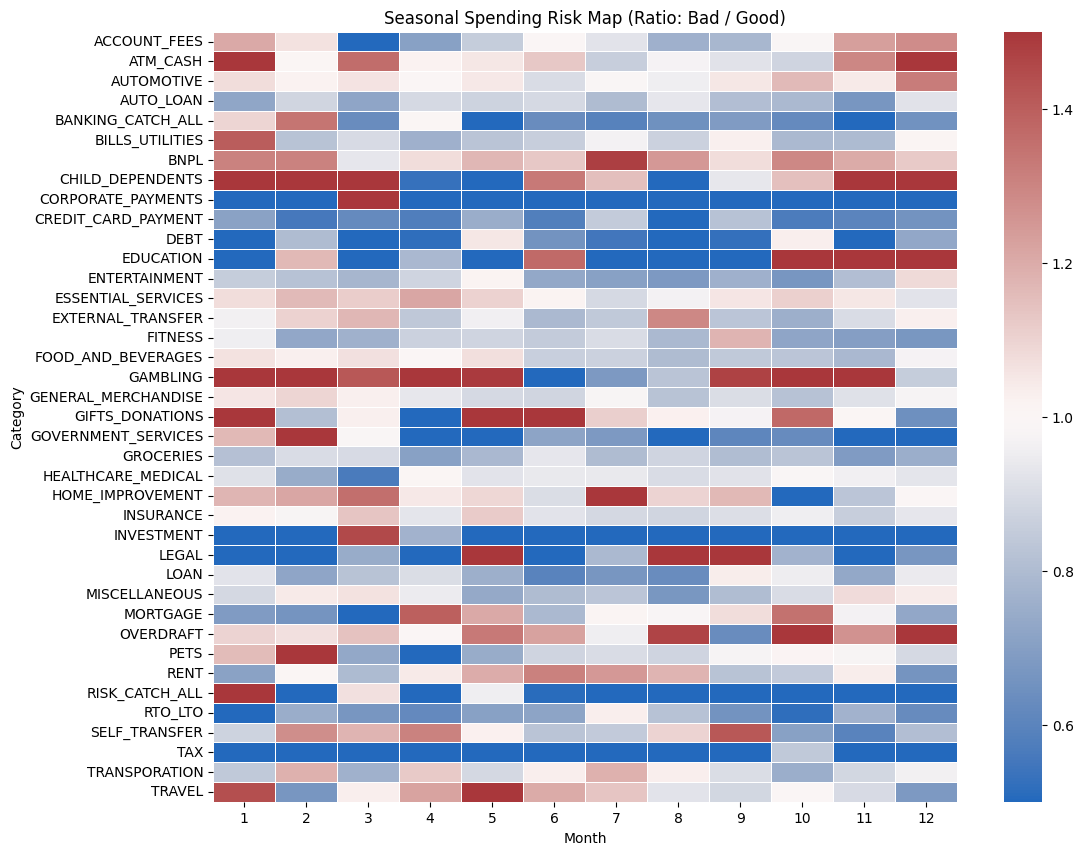

In [220]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

seasonal_df = history_df[history_df['credit_or_debit'] == 'DEBIT'].copy()
seasonal_df['month'] = seasonal_df['posted_date'].dt.month

consumer_seasonality = seasonal_df.groupby([
    'prism_consumer_id', 
    'DQ_TARGET', 
    'category', 
    'month'
])['amount'].sum().reset_index()

class_seasonality = consumer_seasonality.groupby([
    'DQ_TARGET', 
    'category', 
    'month'
])['amount'].mean().reset_index()

good_profile = class_seasonality[class_seasonality['DQ_TARGET'] == 0].pivot(
    index='category', columns='month', values='amount'
).fillna(0)

bad_profile = class_seasonality[class_seasonality['DQ_TARGET'] == 1].pivot(
    index='category', columns='month', values='amount'
).fillna(0)

seasonality_ratio = (bad_profile + 1) / (good_profile + 1)

plt.figure(figsize=(12, 10))
sns.heatmap(
    seasonality_ratio, 
    cmap='vlag',
    center=1.0,
    vmin=0.5, vmax=1.5,
    linewidths=.5
)

plt.title('Seasonal Spending Risk Map (Ratio: Bad / Good)')
plt.xlabel('Month')
plt.ylabel('Category')
plt.show()

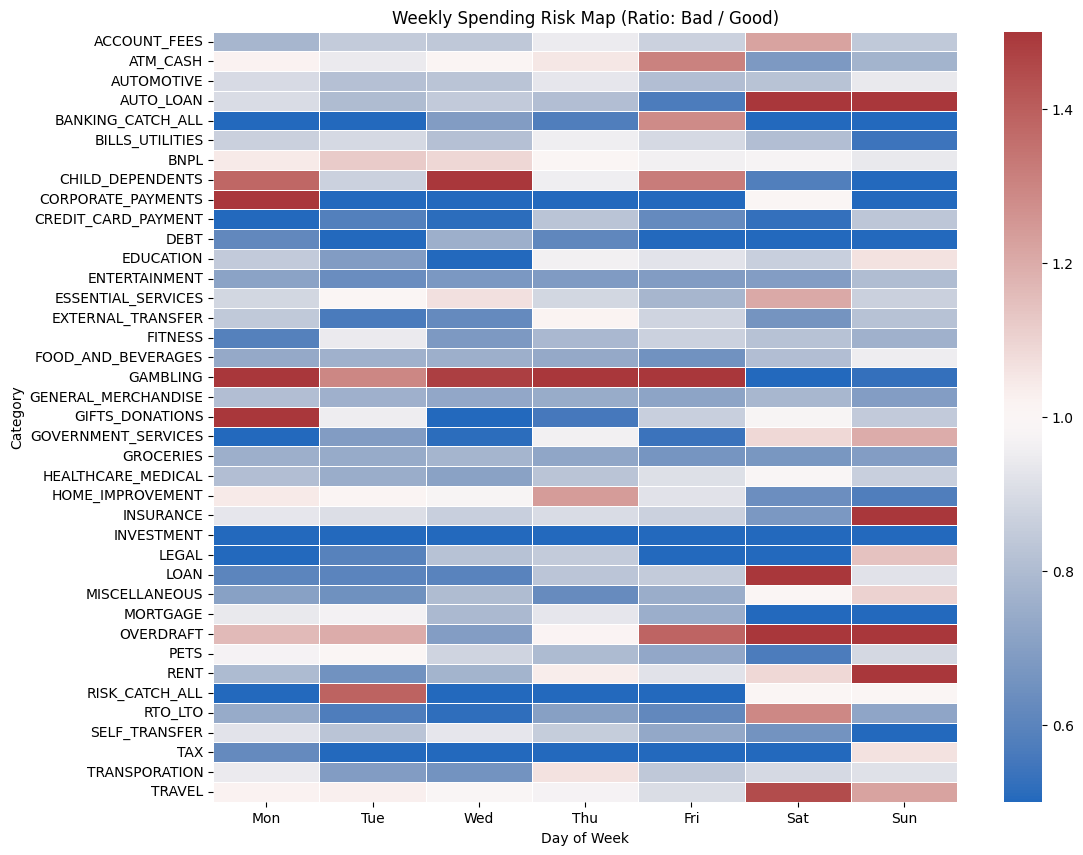

In [238]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

weekly_df = history_df[history_df['credit_or_debit'] == 'DEBIT'].copy()
weekly_df['weekday'] = weekly_df['posted_date'].dt.weekday

consumer_seasonality = weekly_df.groupby([
    'prism_consumer_id', 
    'DQ_TARGET', 
    'category', 
    'weekday'
])['amount'].sum().reset_index()

class_seasonality = consumer_seasonality.groupby([
    'DQ_TARGET', 
    'category', 
    'weekday'
])['amount'].mean().reset_index()

good_profile = class_seasonality[class_seasonality['DQ_TARGET'] == 0].pivot(
    index='category', columns='weekday', values='amount'
).fillna(0)

bad_profile = class_seasonality[class_seasonality['DQ_TARGET'] == 1].pivot(
    index='category', columns='weekday', values='amount'
).fillna(0)

seasonality_ratio = (bad_profile + 1) / (good_profile + 1)

plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    seasonality_ratio, 
    cmap='vlag',
    center=1.0,
    vmin=0.5, vmax=1.5,
    linewidths=.5,
    # Add this line to rename the x-axis labels
    xticklabels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
)

plt.title('Weekly Spending Risk Map (Ratio: Bad / Good)')
plt.xlabel('Day of Week')
plt.ylabel('Category')
plt.show()

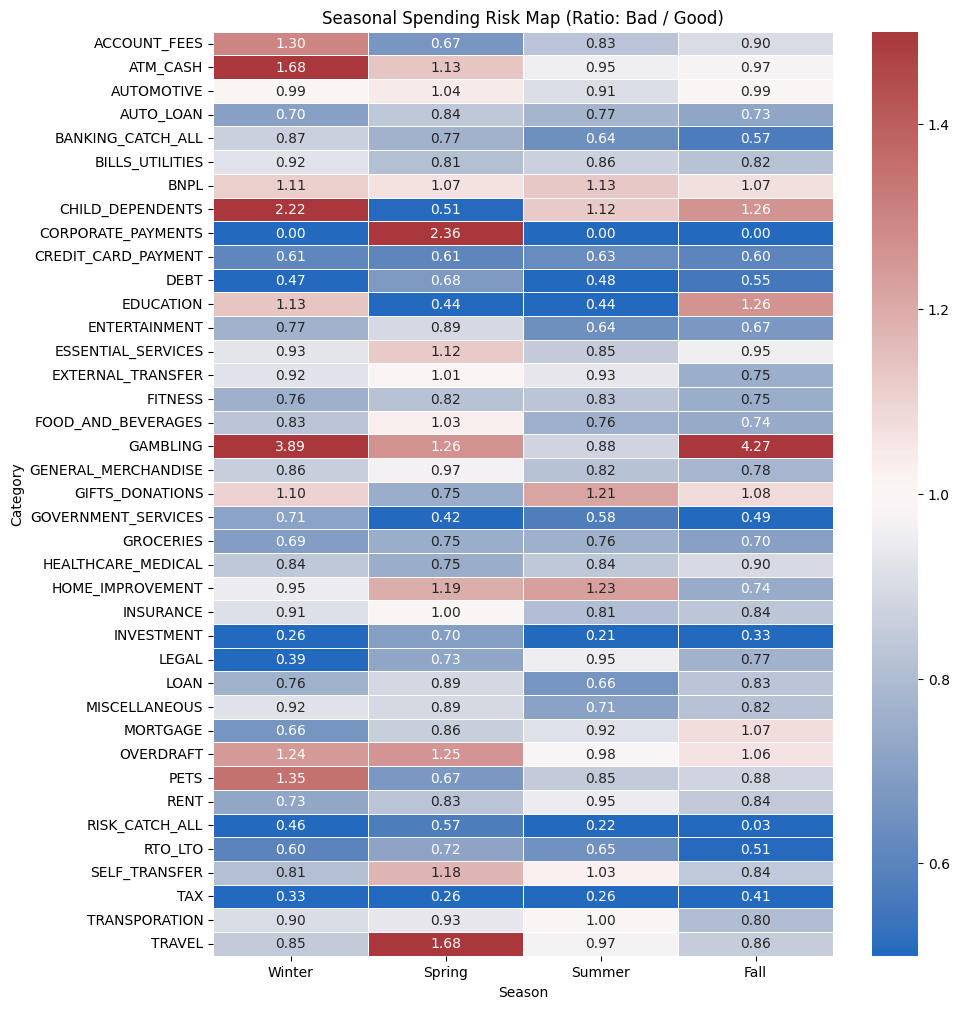

In [221]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare Data
seasonal_df = history_df[history_df['credit_or_debit'] == 'DEBIT'].copy()
seasonal_df['month'] = seasonal_df['posted_date'].dt.month

# 2. Define Your Custom Seasons (Handling Overlaps)
# Note: Month 9 (Sep) is in Summer AND Fall
# Note: Month 11 (Nov) is in Winter AND Fall
def get_seasons(m):
    seasons = []
    if m in [11, 12, 1, 2]:
        seasons.append('Winter')
    if m in [3, 4, 5]:
        seasons.append('Spring')
    if m in [6, 7, 8, 9]:
        seasons.append('Summer')
    if m in [9, 10, 11]:
        seasons.append('Fall')
    return seasons

# Apply the mapping and EXPLODE (duplicate rows for overlapping months)
seasonal_df['season'] = seasonal_df['month'].apply(get_seasons)
seasonal_df = seasonal_df.explode('season')

# 3. Aggregate per Consumer (Sum spending per Season)
consumer_seasonality = seasonal_df.groupby([
    'prism_consumer_id', 
    'DQ_TARGET', 
    'category', 
    'season'
])['amount'].sum().reset_index()

# 4. Aggregate by Class (Mean spending per Season)
class_seasonality = consumer_seasonality.groupby([
    'DQ_TARGET', 
    'category', 
    'season'
])['amount'].mean().reset_index()

# 5. Pivot for Heatmap
good_profile = class_seasonality[class_seasonality['DQ_TARGET'] == 0].pivot(
    index='category', columns='season', values='amount'
).fillna(0)

bad_profile = class_seasonality[class_seasonality['DQ_TARGET'] == 1].pivot(
    index='category', columns='season', values='amount'
).fillna(0)

# Calculate Risk Ratio
seasonality_ratio = (bad_profile + 1) / (good_profile + 1)

# 6. Reorder Columns for Logical Flow
# Standard order: Winter -> Spring -> Summer -> Fall
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
seasonality_ratio = seasonality_ratio.reindex(columns=season_order)

# 7. Plot
plt.figure(figsize=(10, 12))
sns.heatmap(
    seasonality_ratio, 
    cmap='vlag',
    center=1.0,
    vmin=0.5, vmax=1.5,
    linewidths=.5,
    annot=True, # Added numbers to see the exact ratio
    fmt='.2f'
)

plt.title('Seasonal Spending Risk Map (Ratio: Bad / Good)')
plt.xlabel('Season')
plt.ylabel('Category')
plt.show()

In [222]:
risk_map = seasonality_ratio.stack().reset_index(name='risk_ratio')

red_zones = risk_map[risk_map['risk_ratio'] > 1.2].sort_values('risk_ratio', ascending=False).head(10)
red_pairs = set(zip(red_zones['category'], red_zones['season']))

blue_zones = risk_map[risk_map['risk_ratio'] < 0.8].sort_values('risk_ratio', ascending=True).head(10)
blue_pairs = set(zip(blue_zones['category'], blue_zones['season']))

print("Top Risk Combos (Red):", red_pairs)
print("Top Safe Combos (Blue):", blue_pairs)

Top Risk Combos (Red): {('CORPORATE_PAYMENTS', 'Spring'), ('ACCOUNT_FEES', 'Winter'), ('PETS', 'Winter'), ('GAMBLING', 'Winter'), ('EDUCATION', 'Fall'), ('GAMBLING', 'Spring'), ('CHILD_DEPENDENTS', 'Winter'), ('GAMBLING', 'Fall'), ('ATM_CASH', 'Winter'), ('TRAVEL', 'Spring')}
Top Safe Combos (Blue): {('TAX', 'Spring'), ('TAX', 'Winter'), ('INVESTMENT', 'Winter'), ('CORPORATE_PAYMENTS', 'Winter'), ('CORPORATE_PAYMENTS', 'Fall'), ('RISK_CATCH_ALL', 'Fall'), ('CORPORATE_PAYMENTS', 'Summer'), ('RISK_CATCH_ALL', 'Summer'), ('TAX', 'Summer'), ('INVESTMENT', 'Summer')}


In [225]:
spend_df = history_df[history_df['credit_or_debit'] == 'DEBIT'].copy()

# 5. Seasonal Features (Using Names)
def get_seasons(m):
    seasons = []
    if m in [11, 12, 1, 2]: seasons.append('Winter')
    if m in [3, 4, 5]:      seasons.append('Spring')
    if m in [6, 7, 8, 9]:   seasons.append('Summer')
    if m in [9, 10, 11]:    seasons.append('Fall')
    return seasons

seasonal_data = spend_df.copy()
seasonal_data['season_list'] = seasonal_data['posted_date'].dt.month.apply(get_seasons)
seasonal_data = seasonal_data.explode('season_list')

seasonal_features = seasonal_data.pivot_table(
    index='prism_consumer_id',
    columns=['season_list', 'category'], # <--- Uses Name
    values='amount',
    aggfunc='sum',
    fill_value=0
)
seasonal_features.columns = [f'{s}_Cat_{c}' for s, c in seasonal_features.columns]

# 6. Global Stats
raw_stats = spend_df.groupby('prism_consumer_id')['amount'].agg(['mean', 'min', 'max']).add_prefix('trans_global_spend_')

# 7. Monthly Rolling (Using Names)
monthly_baskets = spend_df.groupby([
    'prism_consumer_id', 
    pd.Grouper(key='posted_date', freq='ME'), 
    'category' # <--- Uses Name
])['amount'].sum().unstack(level='category', fill_value=0)

monthly_totals = monthly_baskets.sum(axis=1).to_frame('total_spend')

rolling_dfs = []
for m in [1, 3, 6, 12]:
    cat_roll = monthly_baskets.groupby('prism_consumer_id').rolling(window=m, min_periods=1).agg(['mean', 'max'])
    cat_roll.columns = [f'{col[0]}_{m}m_spend_{col[1]}' for col in cat_roll.columns]
    
    tot_roll = monthly_totals.groupby('prism_consumer_id').rolling(window=m, min_periods=1).agg(['mean', 'min', 'max'])
    tot_roll.columns = [f'{col[0]}_{m}m_{col[1]}' for col in tot_roll.columns]
    
    combined = pd.concat([cat_roll, tot_roll], axis=1)
    rolling_dfs.append(combined.groupby('prism_consumer_id').tail(1).reset_index(level=1, drop=True))

final_rolling = pd.concat(rolling_dfs, axis=1)

# 8. Income Features (Using IDs)
income_cols = [3, 7, 45, 49]
# FIX: Use 'category_id' (int) here, not 'category' (str)
income_mask = history_df['category_id'].isin(income_cols)

monthly_income = history_df[income_mask].groupby([
    'prism_consumer_id', 
    pd.Grouper(key='posted_date', freq='ME')
])['signed_amount'].sum()

def calc_fft_features(series):
    if isinstance(series.index, pd.MultiIndex):
        series = series.droplevel(0)
    series = series.asfreq('ME', fill_value=0)
    n = len(series)
    if n < 2:
        return pd.Series([series.mean(), 0.0], index=['income_fft_dc', 'income_fft_stability'])
    y = fft(series.values)
    dc = np.abs(y[0]) / n
    stability = np.abs(y[1]) / n
    return pd.Series([dc, stability], index=['income_fft_dc', 'income_fft_stability'])

fft_features = monthly_income.groupby('prism_consumer_id').apply(calc_fft_features).unstack()

targets = history_df[['prism_consumer_id', 'DQ_TARGET']].drop_duplicates().set_index('prism_consumer_id')
final_rolling['income_data_missing'] = fft_features['income_fft_dc'].isna().astype(int)

# 9. Final Merge & Cleanup
final_product = (final_rolling
                 .join(raw_stats, how='left')
                 .join(fft_features, how='left')
                 .join(seasonal_features, how='left')
                 .join(targets, how='inner')
                 .fillna(0))

# Clean column names for ML (remove spaces and special chars)
final_product.columns = [
    re.sub(r'[^a-zA-Z0-9_]', '_', str(col)) for col in final_product.columns
]

final_product

,,ACCOUNT_FEES_1m_spend_mean,ACCOUNT_FEES_1m_spend_max,ATM_CASH_1m_spend_mean,ATM_CASH_1m_spend_max,AUTOMOTIVE_1m_spend_mean,AUTOMOTIVE_1m_spend_max,AUTO_LOAN_1m_spend_mean,AUTO_LOAN_1m_spend_max,BANKING_CATCH_ALL_1m_spend_mean,BANKING_CATCH_ALL_1m_spend_max,...,Winter_Cat_OVERDRAFT,Winter_Cat_PETS,Winter_Cat_RENT,Winter_Cat_RISK_CATCH_ALL,Winter_Cat_RTO_LTO,Winter_Cat_SELF_TRANSFER,Winter_Cat_TAX,Winter_Cat_TRANSPORATION,Winter_Cat_TRAVEL,DQ_TARGET
prism_consumer_id,posted_date,,,,,,,,,,,,,,,,,,,,,
0,2021-09-30,0.0,0.0,500.00,500.00,42.43,42.43,0.0,0.0,0.00,0.00,...,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0
1,2021-07-31,0.0,0.0,600.00,600.00,28.74,28.74,0.0,0.0,0.00,0.00,...,0.0,35.43,0.0,0.0,0.0,1489.00,0.00,0.00,0.00,0.0
10,2022-02-28,0.0,0.0,580.00,580.00,77.01,77.01,0.0,0.0,0.00,0.00,...,0.0,0.00,0.0,0.0,0.0,750.00,0.00,5.00,0.00,0.0
1000,2023-02-28,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.00,...,0.0,0.00,0.0,0.0,0.0,15635.65,0.00,0.00,0.00,0.0
10000,2022-03-31,0.0,0.0,0.00,0.00,89.18,89.18,0.0,0.0,0.00,0.00,...,0.0,269.55,0.0,0.0,0.0,0.00,0.00,3239.73,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,2022-02-28,0.0,0.0,0.00,0.00,60.22,60.22,0.0,0.0,0.00,0.00,...,0.0,446.51,0.0,0.0,0.0,2094.00,47.13,0.00,207.54,0.0
995,2021-11-30,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.00,...,0.0,0.00,1136.4,0.0,0.0,0.00,0.00,0.00,0.00,0.0
997,2022-04-30,0.0,0.0,1900.00,1900.00,0.00,0.00,0.0,0.0,0.00,0.00,...,0.0,0.00,0.0,0.0,0.0,19142.20,0.00,0.00,0.00,0.0


In [239]:
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# --- 1. Logistic Regression Section ---
print("--- Logistic Regression ---")
X_log = final_product.drop(columns=['DQ_TARGET'])
y_log = final_product['DQ_TARGET']

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.3, stratify=y_log, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train_log)

lr_train_probs = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_test_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_preds = lr_model.predict(X_test_scaled)

print(f"Train ROC AUC: {roc_auc_score(y_train_log, lr_train_probs):.4f}")
print(f"Test ROC AUC:  {roc_auc_score(y_test_log, lr_test_probs):.4f}")

# --- 2. XGBoost Section ---
print("\n--- XGBoost ---")
# Drop ID columns for XGBoost if they exist
X_xgb = final_product.drop(columns=['DQ_TARGET', 'posted_date', 'prism_consumer_id'], errors='ignore')
y_xgb = final_product['DQ_TARGET']

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb, test_size=0.2, stratify=y_xgb, random_state=42
)

ratio = float(np.sum(y_train_xgb == 0)) / np.sum(y_train_xgb == 1)

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.8,
    colsample_bytree=0.5,
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_train_xgb, y_train_xgb), (X_test_xgb, y_test_xgb)],
    verbose=100
)

xgb_train_probs = xgb_model.predict_proba(X_train_xgb)[:, 1]
xgb_test_probs = xgb_model.predict_proba(X_test_xgb)[:, 1]
xgb_preds = xgb_model.predict(X_test_xgb)

print(f"\nTrain ROC AUC: {roc_auc_score(y_train_xgb, xgb_train_probs):.4f}")
print(f"Test ROC AUC:  {roc_auc_score(y_test_xgb, xgb_test_probs):.4f}")



# Logistic Regression Matrix
cm_lr = confusion_matrix(y_test_log, lr_preds)


# XGBoost Matrix
cm_xgb = confusion_matrix(y_test_xgb, xgb_preds)
cm_lr, cm_xgb

--- Logistic Regression ---
Train ROC AUC: 0.8288
Test ROC AUC:  0.7062

--- XGBoost ---
[0]	validation_0-logloss:0.68946	validation_1-logloss:0.68912
[100]	validation_0-logloss:0.55959	validation_1-logloss:0.57438
[200]	validation_0-logloss:0.51488	validation_1-logloss:0.54096
[300]	validation_0-logloss:0.48343	validation_1-logloss:0.51951
[400]	validation_0-logloss:0.45777	validation_1-logloss:0.50282
[500]	validation_0-logloss:0.43362	validation_1-logloss:0.48663
[600]	validation_0-logloss:0.41167	validation_1-logloss:0.47314
[700]	validation_0-logloss:0.39042	validation_1-logloss:0.46025
[800]	validation_0-logloss:0.37436	validation_1-logloss:0.45176
[900]	validation_0-logloss:0.35513	validation_1-logloss:0.44119
[999]	validation_0-logloss:0.34142	validation_1-logloss:0.43471

Train ROC AUC: 0.9618
Test ROC AUC:  0.7582


(array([[1719,  930],
        [  82,  173]]),
 array([[1442,  324],
        [  75,   95]]))

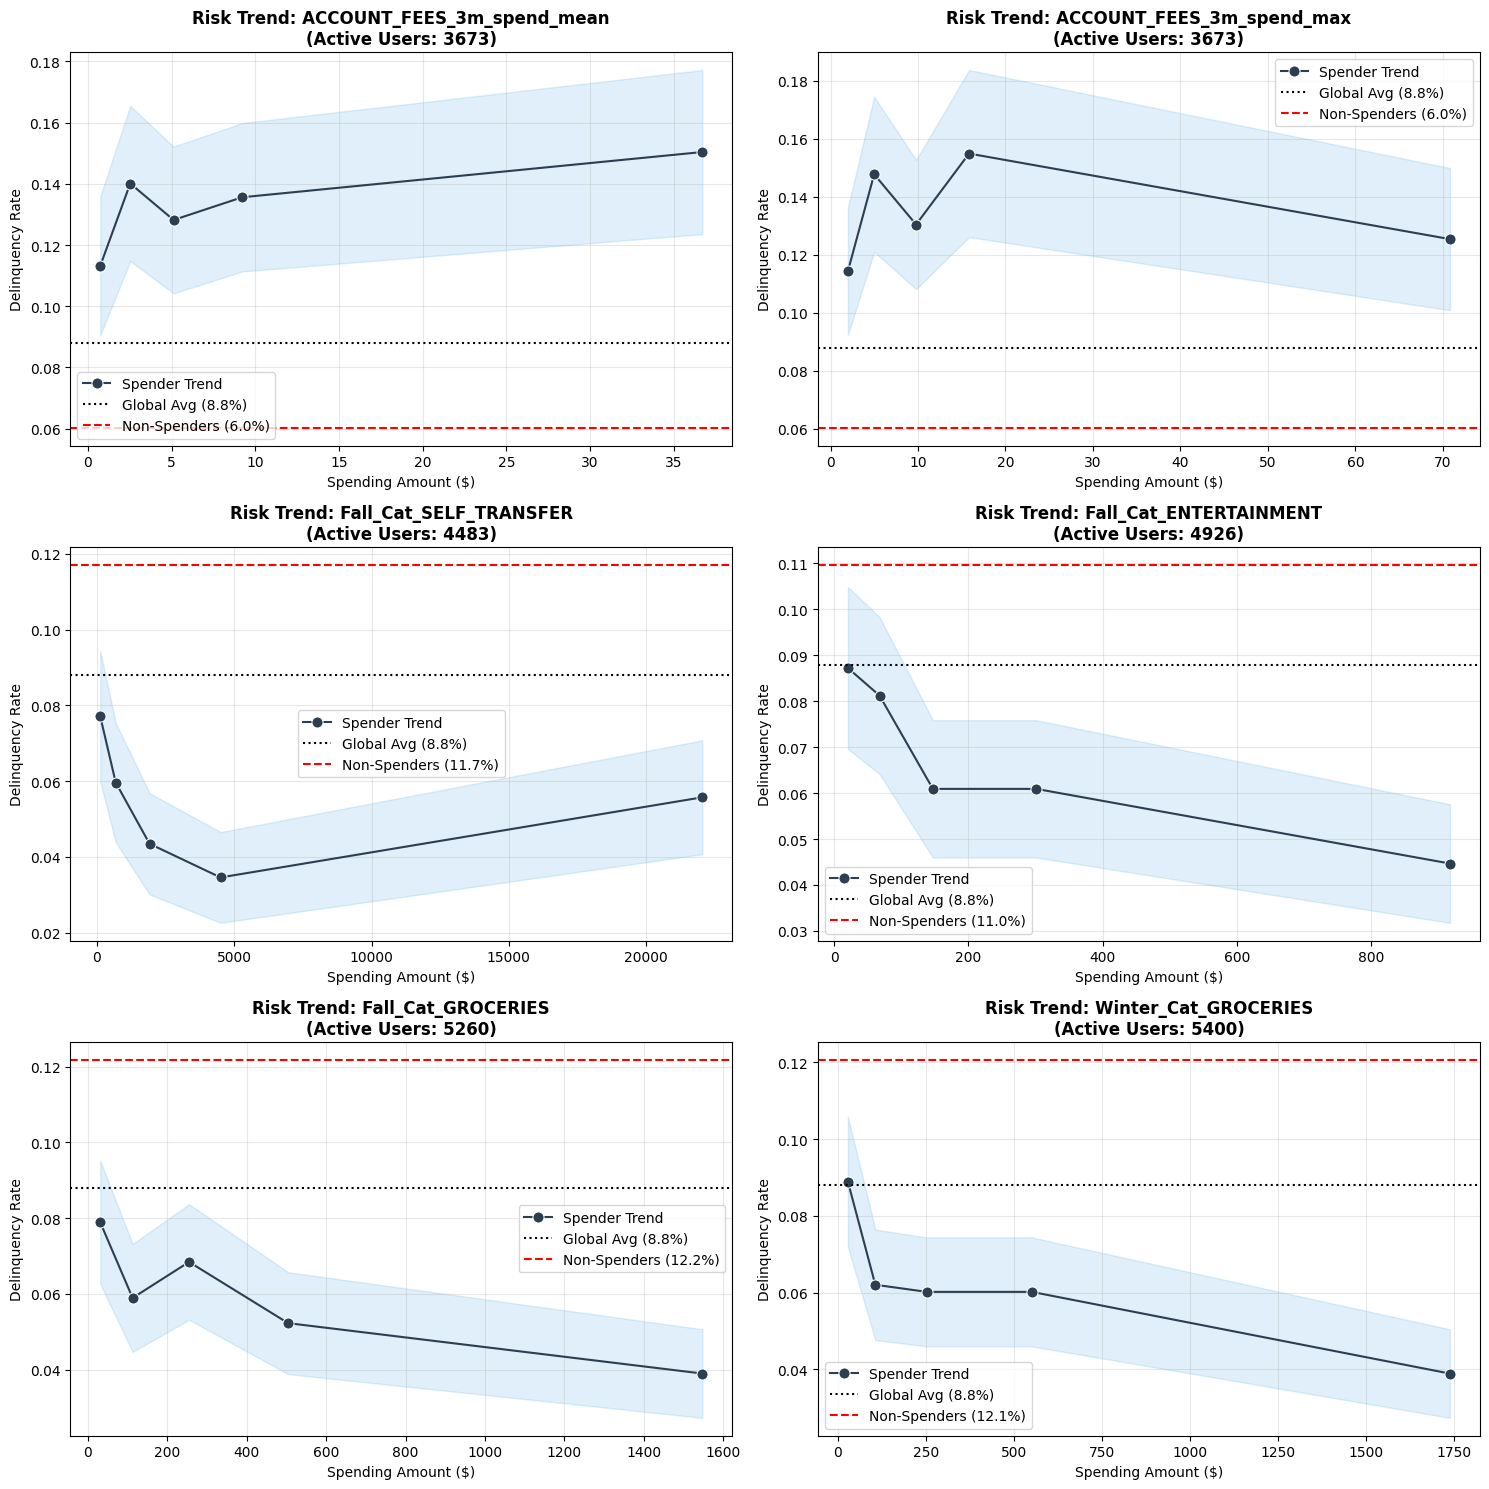

In [233]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


features_to_check = importance_df.head(20)['Feature'].to_list()

sparsity_check = []
for col in features_to_check:
    non_zeros = (final_product[col] != 0).sum()
    total = len(final_product)
    pct_active = non_zeros / total
    
    sparsity_check.append({
        'Feature': col,
        'Active_Users': non_zeros,
        'Pct_Active': f"{pct_active:.1%}",
        'Verdict': 'KEEP' if non_zeros > 100 else 'DROP / FLAG'
    })

sparsity_df = pd.DataFrame(sparsity_check).sort_values('Active_Users')

def plot_risk_trends_nonzero(df, features, target='DQ_TARGET', q=5):
    """
    Plots risk trends for SPENDERS only, with a reference for NON-SPENDERS.
    Using q=5 (Quintiles) because ~200 users is too small for 10 bins.
    """
    n_features = len(features)
    n_cols = 2
    n_rows = (n_features + 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for i, col in enumerate(features):
        ax = axes[i]
        
        # 1. Split Data: Zero vs Non-Zero
        zeros = df[df[col] == 0]
        non_zeros = df[df[col] > 0].copy()
        
        # 2. Calculate Baseline Risks
        global_risk = df[target].mean()
        zero_risk = zeros[target].mean()
        
        # 3. Bin the Non-Zeros (Spenders)
        # We use rank method to handle duplicate values safely
        if len(non_zeros) > 50:
            try:
                non_zeros['bin'] = pd.qcut(non_zeros[col], q=q, duplicates='drop')
            except ValueError:
                 non_zeros['bin'] = pd.qcut(non_zeros[col].rank(method='first'), q=q)
                 
            agg_data = non_zeros.groupby('bin', observed=True).agg({
                col: 'mean',
                target: ['mean', 'sem', 'count']
            })
            agg_data.columns = ['avg_spend', 'risk_rate', 'std_err', 'count']
            agg_data = agg_data.reset_index()

            # 4. Plot the Trend (Spenders)
            sns.lineplot(
                ax=ax, x=agg_data['avg_spend'], y=agg_data['risk_rate'],
                marker='o', markersize=8, color='#2c3e50', label='Spender Trend'
            )
            
            # Error Bands
            lower = agg_data['risk_rate'] - 1.96 * agg_data['std_err']
            upper = agg_data['risk_rate'] + 1.96 * agg_data['std_err']
            ax.fill_between(agg_data['avg_spend'], lower, upper, color='#3498db', alpha=0.15)
            
        else:
            # Fallback for extremely rare features
            ax.text(0.5, 0.5, "Not enough spenders to plot trend", ha='center')

        # 5. Add Reference Lines
        ax.axhline(global_risk, color='black', linestyle=':', label=f'Global Avg ({global_risk:.1%})')
        ax.axhline(zero_risk, color='red', linestyle='--', label=f'Non-Spenders ({zero_risk:.1%})')
        
        ax.set_title(f'Risk Trend: {col}\n(Active Users: {len(non_zeros)})', fontweight='bold')
        ax.set_ylabel('Delinquency Rate')
        ax.set_xlabel('Spending Amount ($)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

sparse_features = sparsity_df["Feature"][-6:].to_list()
plot_risk_trends_nonzero(final_product, sparse_features)

In [228]:
features_to_check = importance_df.head(20)['Feature'].to_list()

sparsity_check = []
for col in features_to_check:
    non_zeros = (final_product[col] != 0).sum()
    total = len(final_product)
    pct_active = non_zeros / total
    
    sparsity_check.append({
        'Feature': col,
        'Active_Users': non_zeros,
        'Pct_Active': f"{pct_active:.1%}",
        'Verdict': 'KEEP' if non_zeros > 100 else 'DROP / FLAG'
    })

sparsity_df = pd.DataFrame(sparsity_check).sort_values('Active_Users')

print("--- Feature Sparsity Diagnosis ---")
print(sparsity_df.to_string(index=False))

--- Feature Sparsity Diagnosis ---
                      Feature  Active_Users Pct_Active Verdict
 GIFTS_DONATIONS_1m_spend_max           320       3.3%    KEEP
GIFTS_DONATIONS_1m_spend_mean           320       3.3%    KEEP
          Spring_Cat_MORTGAGE           462       4.8%    KEEP
          Winter_Cat_GAMBLING           491       5.1%    KEEP
          Summer_Cat_GAMBLING           526       5.4%    KEEP
               Summer_Cat_TAX           565       5.8%    KEEP
            Fall_Cat_MORTGAGE           713       7.4%    KEEP
          Summer_Cat_MORTGAGE           741       7.7%    KEEP
      OVERDRAFT_3m_spend_mean          1355      14.0%    KEEP
      OVERDRAFT_6m_spend_mean          1670      17.3%    KEEP
      INVESTMENT_6m_spend_max          2136      22.1%    KEEP
     INVESTMENT_12m_spend_max          2275      23.5%    KEEP
            BNPL_3m_spend_max          2571      26.6%    KEEP
           BNPL_3m_spend_mean          2571      26.6%    KEEP
   ACCOUNT_FEES_3m_s

In [232]:
sparsity_df["Feature"][-6:].to_list()

['ACCOUNT_FEES_3m_spend_mean',
 'ACCOUNT_FEES_3m_spend_max',
 'Fall_Cat_SELF_TRANSFER',
 'Fall_Cat_ENTERTAINMENT',
 'Fall_Cat_GROCERIES',
 'Winter_Cat_GROCERIES']